In [1]:
from py_files.setup import *
setup_notebook()

import py_files.inverse_leontif_NX as il_NX

# 1. `Industry use decomposition`

In [2]:
# Run full time series with GDP normalization
years = range(1966, 2025) 
investment_timeseries = il.compute_investment_timeseries(
    years, 
    normalize_by_gdp=True  
)

Processing year 1966...
Processing year 1967...
Processing year 1968...
Processing year 1969...
Processing year 1970...
Processing year 1971...
Processing year 1972...
Processing year 1973...
Processing year 1974...
Processing year 1975...
Processing year 1976...
Processing year 1977...
Processing year 1978...
Processing year 1979...
Processing year 1980...
Processing year 1981...
Processing year 1982...
Processing year 1983...
Processing year 1984...
Processing year 1985...
Processing year 1986...
Processing year 1987...
Processing year 1988...
Processing year 1989...
Processing year 1990...
Processing year 1991...
Processing year 1992...
Processing year 1993...
Processing year 1994...
Processing year 1995...
Processing year 1996...
Processing year 1997...
Processing year 1998...
Processing year 1999...
Processing year 2000...
Processing year 2001...
Processing year 2002...
Processing year 2003...
Processing year 2004...
Processing year 2005...
Processing year 2006...
Processing year 

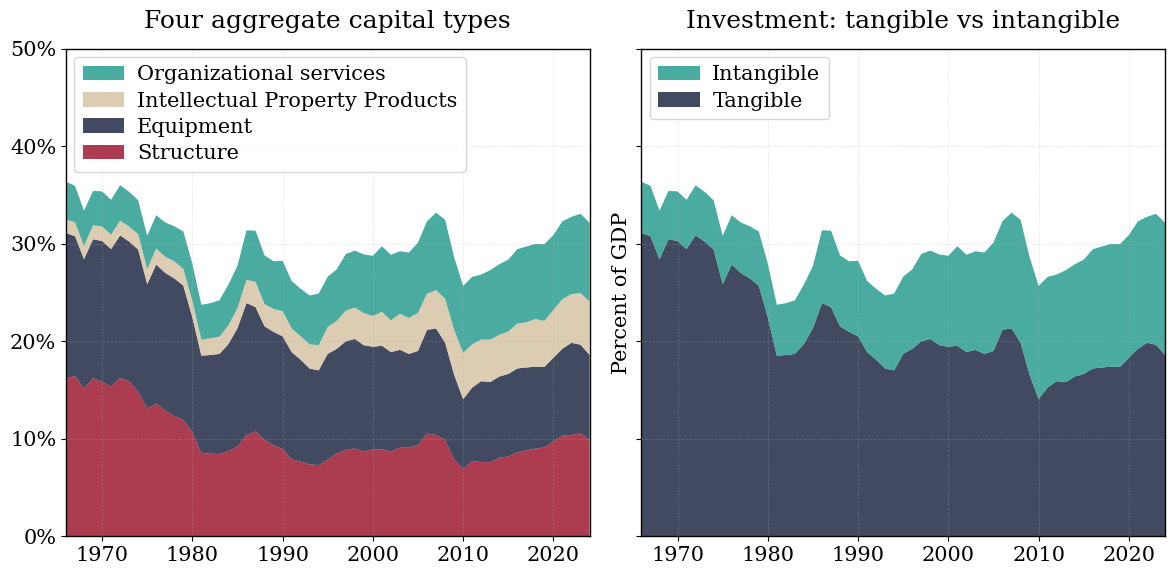

In [7]:
# Create plot (as % of GDP)
il.plot_investment_composition(
    investment_timeseries, 
    as_pct_gdp=True
)

In [4]:
# Run full time series with GDP normalization
years = range(1966, 2025) 
investment_timeseries = il_NX.compute_investment_timeseries(
    years, 
    normalize_by_gdp=True  
)

Processing year 1966...
Processing year 1967...
Processing year 1968...
Processing year 1969...
Processing year 1970...
Processing year 1971...
Processing year 1972...
Processing year 1973...
Processing year 1974...
Processing year 1975...
Processing year 1976...
Processing year 1977...


KeyboardInterrupt: 

In [ ]:
# Check the results
print("\nInvestment as % of GDP:")
print(investment_timeseries[
    ['structures', 'equipment', 'intellectual_property', 'organizational']]
)


Investment as % of GDP:
      structures  equipment  intellectual_property  organizational
year                                                              
1966   16.159576  14.948385               1.376263        3.881729
1967   16.457394  14.324748               1.430261        3.736818
1968   15.135549  13.280761               1.358452        3.622055
1969   16.216161  14.248361               1.435133        3.532178
1970   15.815695  14.469977               1.488869        3.601117
1971   15.365913  14.089693               1.487514        3.571021
1972   16.226095  14.637912               1.509667        3.626973
1973   15.909144  14.317413               1.529137        3.569987
1974   14.819676  14.592393               1.595632        3.459928
1975   13.080105  12.773007               1.540826        3.427076
1976   13.622578  14.247648               1.655022        3.406277
1977   12.882792  14.132809               1.650574        3.525233
1978   12.348967  14.101297          

In [ ]:
# Run for a single year and compare use share weights
old = il.compute_leontief_for_year(2020)
new = il_NX.compute_leontief_for_year(2020)

# Compare: how much weight does each industry get in the I-sector?
comparison = pd.DataFrame({
    'I_share_old': old['use_shares']['I_share'],
    'I_share_new': new['use_shares']['I_share'],
    'X_share_new': new['use_shares']['X_share'],
})
comparison['diff'] = comparison['I_share_new'] - comparison['I_share_old']
print(comparison.sort_values('diff').head(20))

Processing year 2020...
Processing year 2020...
       I_share_old  I_share_new  X_share_new       diff
21000    75.597181     8.942609    88.170711 -66.654572
28000    81.704528    19.563615    76.055654 -62.140913
72001    86.155865    32.759650    61.976297 -53.396215
27000    67.008275    14.693844    78.071598 -52.314431
26000    76.302563    25.021998    67.206871 -51.280565
24000    60.239109    13.759784    77.158056 -46.479325
20000    46.871387     8.319146    82.251121 -38.552241
25000    64.533685    28.048603    56.536494 -36.485083
31320    46.522024    13.420323    71.152753 -33.101701
22000    46.492617    13.706869    70.518181 -32.785748
29000    52.428741    19.974398    61.901815 -32.454342
30000    52.624092    24.280466    53.860551 -28.343626
16000    67.591952    41.820217    38.128408 -25.771735
33000    42.323483    17.598682    58.418635 -24.724801
71000    55.619126    32.578291    41.426101 -23.040836
06090    34.308212    12.110656    64.700417 -22.197556


In [ ]:
result =il_NX.compute_leontief_for_year(2017)
use_shares = result['use_shares']

gdp = il_NX.fetch_gdp_data([2017]).iloc[0]

table = (use_shares[['C_share', 'I_share', 'X_share']]
         .rename(columns={
             'C_share': 'C (%)',
             'I_share': 'I (%)',
             'X_share': 'X (%)'
         })
         .round(1))

table.insert(0, 'Uses/GDP', (use_shares['output'] / gdp * 100).round(1))
table.head(60)

Processing year 2017...


,Uses/GDP,C (%),I (%),X (%)
01000,3.5,25.0,1.3,73.7
02000,0.2,34.8,10.3,54.9
03000,0.2,8.5,0.3,91.2
06090,1.4,24.3,6.2,69.5
10120,6.9,27.7,1.2,71.1
13150,0.4,21.0,8.3,70.6
16000,0.5,16.3,38.0,45.7
17000,0.4,20.1,7.0,72.8
18000,0.4,35.9,16.9,47.1
19000,1.2,35.8,5.2,59.1
